In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

## Download data from OBSEA repository


Execute the script to download the data from the OBSEA repository.


In [2]:
! python -m scripts.get-dataset --help

Usage: python -m scripts [-h]
                         [--log_level {DEBUG,INFO,WARNING,ERROR,CRITICAL}]
                         [--version str]

This script provides a command-line interface to

Options:
  -h, --help            show this help message and exit
  --log_level {DEBUG,INFO,WARNING,ERROR,CRITICAL}
                        Set the logging level. (default: INFO)
  --version str         Dataset version to download. (default: v3.1)


For this example, we will use the default dataset version 3.1.


In [3]:
! python -m scripts.get-dataset --version=v3.1

[03/11/25 17:10:27] INFO     INFO:__main__:Dataset script with ]8;id=490446;file:///home/borja/projects/obsea-fish-detection/scripts/get-dataset.py\get-dataset.py]8;;\:]8;id=758464;file:///home/borja/projects/obsea-fish-detection/scripts/get-dataset.py#43\43]8;;\
                             log level: INFO                                    
                    INFO     INFO:__main__:Downloading dataset ]8;id=720670;file:///home/borja/projects/obsea-fish-detection/scripts/get-dataset.py\get-dataset.py]8;;\:]8;id=144428;file:///home/borja/projects/obsea-fish-detection/scripts/get-dataset.py#45\45]8;;\
                             version: v3.1                                      
                    INFO     INFO:root:Zip file already exists.      ]8;id=722095;file:///home/borja/projects/obsea-fish-detection/obsea/datasets/utils.py\utils.py]8;;\:]8;id=465581;file:///home/borja/projects/obsea-fish-detection/obsea/datasets/utils.py#23\23]8;;\
                    

## Train autoencoder


Execute the script to generate and train an autoencoder.


In [4]:
! python -m scripts.new-autoencoder --help

Usage: python -m scripts [-h]
                         [--log_level {DEBUG,INFO,WARNING,ERROR,CRITICAL}]
                         [--output str] [--version str] [--batch_size int]
                         [--shuffle bool] [--latent_dim int] [--epochs int]
                         [--validation_split float] [--learning_rate float]
                         [--sparsity_weight float]
                         [--early_stopping {int,null}]

This script provides a command-line interface to train a sparse autoencoder.

Options:
  -h, --help            show this help message and exit
  --log_level {DEBUG,INFO,WARNING,ERROR,CRITICAL}
                        Set the logging level. (default: INFO)
  --output str          Output name for the autoencoder model. (default:
                        autoencoder-202503111710)
  --version str         Dataset version to use for training. (default: v3.1)
  --batch_size int      Batch size for the dataloader. (default: 4)
  --shuffle bool        Shuffle the d

For this example, we will use the default autoencoder configuration with an early stopping patience of 3 iterations.


In [5]:
! python -m scripts.new-autoencoder --output=autoencoder --early_stopping=3

[03/11/25 17:10:39] INFO     INFO:__main__:Dataset script  ]8;id=695739;file:///home/borja/projects/obsea-fish-detection/scripts/new-autoencoder.py\new-autoencoder.py]8;;\:]8;id=999471;file:///home/borja/projects/obsea-fish-detection/scripts/new-autoencoder.py#87\87]8;;\
                             with log level: INFO                               
                    INFO     INFO:__main__:Loading         ]8;id=537179;file:///home/borja/projects/obsea-fish-detection/scripts/new-autoencoder.py\new-autoencoder.py]8;;\:]8;id=827788;file:///home/borja/projects/obsea-fish-detection/scripts/new-autoencoder.py#89\89]8;;\
                             settings file for version                          
                             v3.1                                               
                    INFO     INFO:__main__:Creating image  ]8;id=942907;file:///home/borja/projects/obsea-fish-detection/scripts/new-autoencoder.py\new-autoencoder.py]8;;\:]8;id=195880;file://

Once the training is completed, we can load the autoencoder and test it.


In [6]:
with open("models/autoencoder.pt", "rb") as f:
    autoencoder = torch.load(f, weights_only=False).to("cpu")
autoencoder.eval()

Autoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
      (5): Linear(in_features=165888, out_features=200, bias=True)
      (6): ReLU()
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Linear(in_features=200, out_features=165888, bias=True)
      (1): ReLU()
      (2): Unflatten(dim=1, unflattened_size=(32, 54, 96))
      (3): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (4): ReLU()
      (5): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (6): Sigmoid()
    )
  )
)

Load an example image from the images folder.


In [7]:
image_path = "datasets/obsea_dataset_v3.1/images/20230728-083036-IPC608_8B64_165.jpg"
image = Image.open(image_path).convert("RGB")
image = image.resize((384, 216))

Convert image to tensor and normalize it.


In [8]:
image_tensor = torch.tensor(np.array(image)) / 255.0
image_tensor = image_tensor.permute(2, 0, 1).unsqueeze(0).float()

Pass the image through the autoencoder


In [9]:
with torch.no_grad():
    encoded_image = autoencoder.encoder(image_tensor)
    decoded_image = autoencoder.decoder(encoded_image)

Convert the decoded image back to a PIL image


In [10]:
decoded_image = decoded_image.squeeze().permute(1, 2, 0).numpy()
decoded_image = (decoded_image * 255).astype(np.uint8)
decoded_image = Image.fromarray(decoded_image)

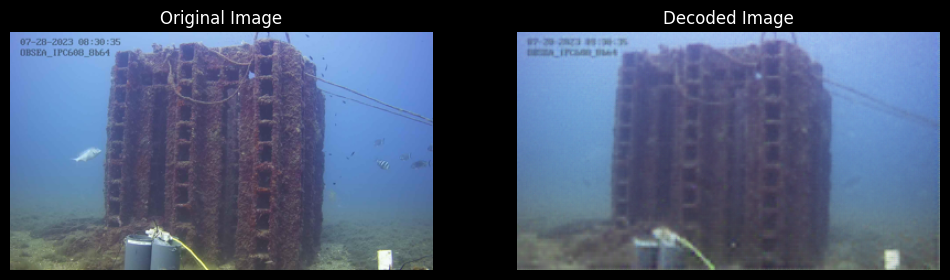

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(decoded_image)
axes[1].set_title("Decoded Image")
axes[1].axis("off")

plt.show()

## Encode dataset


In this section, we will use the trained autoencoder to encode the dataset.


In [12]:
! python -m scripts.encode-data --help

Usage: python -m scripts [-h]
                         [--log_level {DEBUG,INFO,WARNING,ERROR,CRITICAL}]
                         [--version str] [--autoencoder str]

This script provides a command-line interface to

Options:
  -h, --help            show this help message and exit
  --log_level {DEBUG,INFO,WARNING,ERROR,CRITICAL}
                        Set the logging level. (default: INFO)
  --version str         Dataset version to encode. (default: v3.1)
  --autoencoder str     Autoencoder to use for encoding. (default:
                        autoencoder)


Execute the script to encode the correct dataset version 3.1.


In [13]:
! python -m scripts.encode-data --version=v3.1

[03/11/25 17:12:46] INFO     INFO:__main__:Dataset script with ]8;id=805781;file:///home/borja/projects/obsea-fish-detection/scripts/encode-data.py\encode-data.py]8;;\:]8;id=7366;file:///home/borja/projects/obsea-fish-detection/scripts/encode-data.py#49\49]8;;\
                             log level: INFO                                    
                    INFO     INFO:__main__:Loading autoencoder ]8;id=814363;file:///home/borja/projects/obsea-fish-detection/scripts/encode-data.py\encode-data.py]8;;\:]8;id=740296;file:///home/borja/projects/obsea-fish-detection/scripts/encode-data.py#51\51]8;;\
                             model from autoencoder                             
                    INFO     INFO:__main__:Loading settings    ]8;id=858646;file:///home/borja/projects/obsea-fish-detection/scripts/encode-data.py\encode-data.py]8;;\:]8;id=196271;file:///home/borja/projects/obsea-fish-detection/scripts/encode-data.py#54\54]8;;\
                        

We can load the encodings and check the shape of the encoded dataset.


In [14]:
with open("encoded/v3.1_autoencoder_clean.pt", "rb") as f:
    encodings_clean = torch.load(f).to("cpu")
print(f"Clean Encodings Shape: {encodings_clean.shape}")

Clean Encodings Shape: torch.Size([16, 200])


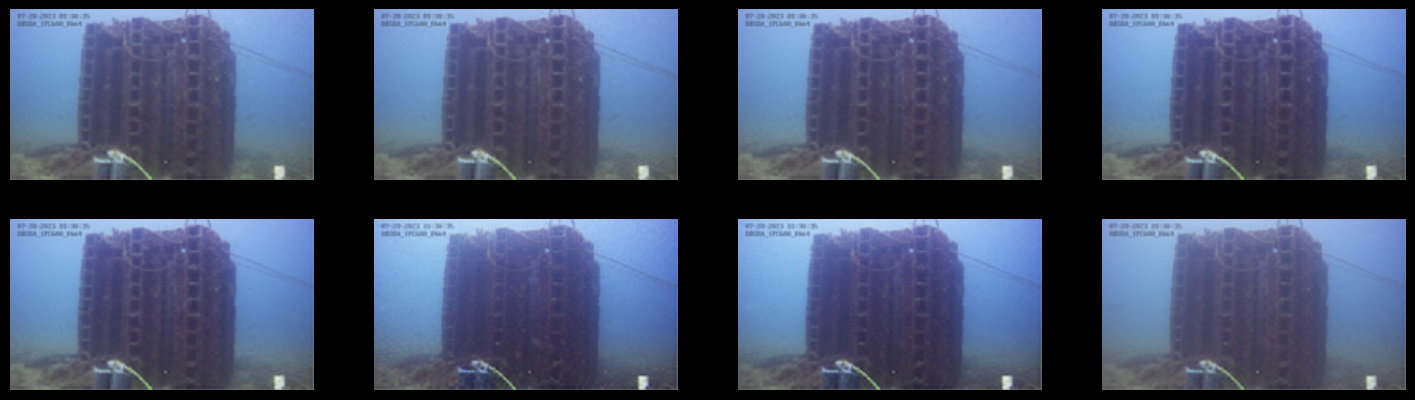

In [15]:
decoded = autoencoder.decoder(encodings_clean[:20])

fig, axes = plt.subplots(2, 4, figsize=(18, 5))
for image, ax in zip(decoded, axes.flatten()):
    img = image.permute(1, 2, 0).detach().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")

In [16]:
with open("encoded/v3.1_autoencoder_dirty.pt", "rb") as f:
    encodings_dirty = torch.load(f).to("cpu")
print(f"Dirty Encodings Shape: {encodings_dirty.shape}")

Dirty Encodings Shape: torch.Size([12, 200])


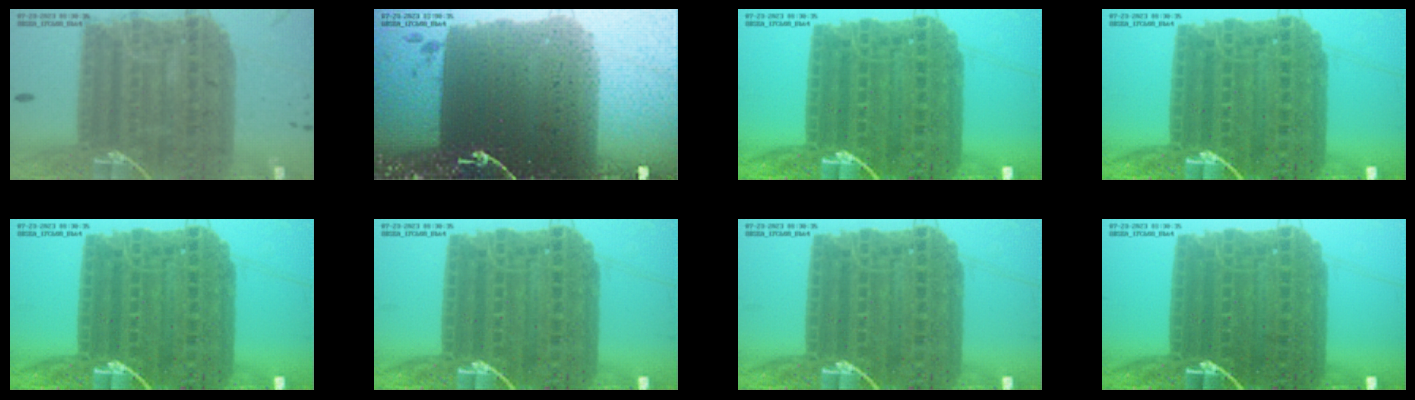

In [17]:
decoded = autoencoder.decoder(encodings_dirty[:20])

fig, axes = plt.subplots(2, 4, figsize=(18, 5))
for image, ax in zip(decoded, axes.flatten()):
    img = image.permute(1, 2, 0).detach().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")

## Train detector


Finally we can train the detector.


In [18]:
! python -m scripts.new-detector --help

Usage: python -m scripts [-h]
                         [--log_level {DEBUG,INFO,WARNING,ERROR,CRITICAL}]
                         [--output str] [--encoded str] [--sigma float]
                         [--permutations int]

This script provides a command-line interface to train a drift detector.

Options:
  -h, --help            show this help message and exit
  --log_level {DEBUG,INFO,WARNING,ERROR,CRITICAL}
                        Set the logging level. (default: INFO)
  --output str          Output name for the drift detector. (default:
                        ddetector-202503111712)
  --encoded str         Encoded torch object with training tensors. (default:
                        v3.1_autoencoder_clean)
  --sigma float         Sigma value for the RBF kernel. (default: 0.5)
  --permutations int    Number of permutations for the permutation test.
                        (default: 100)


In this example, we output the detector "ddetector.pkl" (drift detector) as pickle file.


In [19]:
! python -m scripts.new-detector --output=ddetector

INFO:__main__:New detector script with log level: INFO
INFO:__main__:Loading encoded data from: v3.1_autoencoder_clean
INFO:__main__:Creating drift detector based on <class 'frouros.detectors.data_drift.batch.distance_based.mmd.MMD'>
INFO:__main__:Fitting drift detector with encoded data
INFO:__main__:Saving drift detector to: ddetector


Now we can load the detector and test the performance.


In [20]:
with open("models/ddetector.pkl", "rb") as f:
    detector = pickle.load(f)
detector

MMD(callbacks=[PermutationTestDistanceBased(name='PermutationTestDistanceBased')], data_type=NumericalData(output_type=<class 'numpy.float32'>), statistical_type=MultivariateData(im_check=<built-in function ge>))

In [21]:
_, callback_logs = detector.compare(X=encodings_dirty.cpu().numpy())
p_value = callback_logs["PermutationTestDistanceBased"]["p_value"]
print(f"p-value: {round(p_value, 4)}")

p-value: 0.0099


In [22]:
if p_value <= (alpha := 0.05):
    print("Data drift detected")
else:
    print("No data drift detected")

Data drift detected
